<a href="https://colab.research.google.com/github/hemanginivyas3/itaassignment/blob/main/Project1ITA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassan06/nslkdd")

print("Path to dataset files:", path)

# Task
Analyze the NSL-KDD dataset downloaded from `kagglehub.dataset_download("hassan06/nslkdd")`, focusing on: loading and inspecting the data; preprocessing features; applying K-Means clustering; preparing data for supervised learning; training and evaluating Decision Tree, Random Forest, and Deep Neural Network models; analyzing feature importance; and summarizing findings.

## Load and Inspect Data

### Subtask:
Load the NSL-KDD dataset from the path provided by kagglehub and perform an initial inspection of its structure, columns, and data types.


**Reasoning**:
To load and inspect the NSL-KDD datasets, I need to import the pandas library, construct the file paths for the training and testing data, load them into separate DataFrames, and then display their head, info, and descriptive statistics.



In [ ]:
import pandas as pd

# Construct full paths to the dataset files
train_file_path = path / 'KDDTrain+.txt'
test_file_path = path / 'KDDTest+.txt'

# Load the training dataset
train_df = pd.read_csv(train_file_path, sep=',', header=None)
print("\n--- Training Data (train_df) ---")
print("First 5 rows of train_df:")
print(train_df.head())
print("\nInformation about train_df:")
train_df.info()
print("\nDescriptive statistics for train_df:")
print(train_df.describe())

# Load the test dataset
test_df = pd.read_csv(test_file_path, sep=',', header=None)
print("\n--- Test Data (test_df) ---")
print("First 5 rows of test_df:")
print(test_df.head())
print("\nInformation about test_df:")
test_df.info()
print("\nDescriptive statistics for test_df:")
print(test_df.describe())

NameError: name 'path' is not defined

**Reasoning**:
The previous code failed because the 'path' variable, which holds the dataset's download location, was not defined in the execution context of the failing cell. I need to re-include the `kagglehub.dataset_download` call to ensure 'path' is available before attempting to construct file paths.



In [ ]:
import pandas as pd
import kagglehub

# Download latest version to ensure 'path' is defined
path = kagglehub.dataset_download("hassan06/nslkdd")

# Construct full paths to the dataset files
train_file_path = path / 'KDDTrain+.txt'
test_file_path = path / 'KDDTest+.txt'

# Load the training dataset
train_df = pd.read_csv(train_file_path, sep=',', header=None)
print("\n--- Training Data (train_df) ---")
print("First 5 rows of train_df:")
print(train_df.head())
print("\nInformation about train_df:")
train_df.info()
print("\nDescriptive statistics for train_df:")
print(train_df.describe())

# Load the test dataset
test_df = pd.read_csv(test_file_path, sep=',', header=None)
print("\n--- Test Data (test_df) ---")
print("First 5 rows of test_df:")
print(test_df.head())
print("\nInformation about test_df:")
test_df.info()
print("\nDescriptive statistics for test_df:")
print(test_df.describe())

Using Colab cache for faster access to the 'nslkdd' dataset.


TypeError: unsupported operand type(s) for /: 'str' and 'str'

**Reasoning**:
The error `TypeError: unsupported operand type(s) for /: 'str' and 'str'` indicates that the `path` variable is a string, and direct division with another string for path concatenation is not supported. I need to convert the `path` variable into a `pathlib.Path` object to enable the use of the `/` operator for robust path construction.



In [ ]:
import pandas as pd
import kagglehub
from pathlib import Path

# Download latest version to ensure 'path' is defined
path_str = kagglehub.dataset_download("hassan06/nslkdd")
path = Path(path_str)

# Construct full paths to the dataset files
train_file_path = path / 'KDDTrain+.txt'
test_file_path = path / 'KDDTest+.txt'

# Load the training dataset
train_df = pd.read_csv(train_file_path, sep=',', header=None)
print("\n--- Training Data (train_df) ---")
print("First 5 rows of train_df:")
print(train_df.head())
print("\nInformation about train_df:")
train_df.info()
print("\nDescriptive statistics for train_df:")
print(train_df.describe())

# Load the test dataset
test_df = pd.read_csv(test_file_path, sep=',', header=None)
print("\n--- Test Data (test_df) ---")
print("First 5 rows of test_df:")
print(test_df.head())
print("\nInformation about test_df:")
test_df.info()
print("\nDescriptive statistics for test_df:")
print(test_df.describe())

Using Colab cache for faster access to the 'nslkdd' dataset.

--- Training Data (train_df) ---
First 5 rows of train_df:
   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]

Information about train_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 12597

## Preprocess Features

### Subtask:
Identify categorical and numerical features. Apply appropriate encoding (e.g., one-hot encoding) to categorical features and scale numerical features to prepare the data for machine learning models.


**Reasoning**:
The first step is to define the column names for the NSL-KDD dataset and assign them to both the training and testing DataFrames, as the raw data was loaded without headers.



In [ ]:
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'difficulty_score'
]

train_df.columns = column_names
test_df.columns = column_names

print("Train DataFrame columns updated:")
print(train_df.head())
print("\nTest DataFrame columns updated:")
print(test_df.head())

Train DataFrame columns updated:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60              

**Reasoning**:
Now that the column names are assigned, I need to separate the features (X) from the target variable (y) for both the training and testing datasets. The target variable is specified as 'attack_type', and the 'difficulty_score' column is also a target-related column that should be excluded from features.



In [ ]:
X_train = train_df.drop(['attack_type', 'difficulty_score'], axis=1)
y_train = train_df['attack_type']

X_test = test_df.drop(['attack_type', 'difficulty_score'], axis=1)
y_test = test_df['attack_type']

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (125973, 41)
Shape of y_train: (125973,)
Shape of X_test: (22544, 41)
Shape of y_test: (22544,)


**Reasoning**:
To identify categorical and numerical features, I will iterate through the columns of `X_train` and `X_test` and check their data types. I'll explicitly define categorical features as those with `object` dtype, and numerical features as those with `int64` or `float64` dtype.



In [ ]:
categorical_features_X_train = X_train.select_dtypes(include=['object']).columns
numerical_features_X_train = X_train.select_dtypes(include=['int64', 'float64']).columns

categorical_features_X_test = X_test.select_dtypes(include=['object']).columns
numerical_features_X_test = X_test.select_dtypes(include=['int64', 'float64']).columns

print("Categorical features in X_train:", list(categorical_features_X_train))
print("Numerical features in X_train:", list(numerical_features_X_train))
print("\nCategorical features in X_test:", list(categorical_features_X_test))
print("Numerical features in X_test:", list(numerical_features_X_test))

Categorical features in X_train: ['protocol_type', 'service', 'flag']
Numerical features in X_train: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

Categorical features in X_test: ['protocol_type', 'service', 'flag']
Numerical features in X_test: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'lo

**Reasoning**:
The next step is to apply LabelEncoder to the target variables `y_train` and `y_test` to convert attack type strings into numerical labels, which is required for most machine learning models.



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to y_train and y_test
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Original y_train head:\n", y_train.head())
print("Encoded y_train head:\n", y_train_encoded[:5])
print("Original y_test head:\n", y_test.head())
print("Encoded y_test head:\n", y_test_encoded[:5])
print("Unique classes and their encoded values:", list(label_encoder.classes_))


ValueError: y contains previously unseen labels: 'saint'

**Reasoning**:
The `ValueError` occurred because `y_test` contained a label ('saint') that was not present in `y_train` when the `LabelEncoder` was fitted. To resolve this, the `LabelEncoder` must be fitted on all unique labels present in both `y_train` and `y_test` before transforming either. I will combine the unique labels from both datasets to fit the encoder.



In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit LabelEncoder on the combined unique labels from both y_train and y_test
# This ensures that all possible labels are known to the encoder
all_unique_labels = np.unique(np.concatenate((y_train, y_test)))
label_encoder.fit(all_unique_labels)

# Apply LabelEncoder to y_train and y_test
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Original y_train head:\n", y_train.head())
print("Encoded y_train head:\n", y_train_encoded[:5])
print("Original y_test head:\n", y_test.head())
print("Encoded y_test head:\n", y_test_encoded[:5])
print("Unique classes and their encoded values:", list(label_encoder.classes_))

Original y_train head:
 0     normal
1     normal
2    neptune
3     normal
4     normal
Name: attack_type, dtype: object
Encoded y_train head:
 [16 16 14 16 16]
Original y_test head:
 0    neptune
1    neptune
2     normal
3      saint
4      mscan
Name: attack_type, dtype: object
Encoded y_test head:
 [14 14 16 24 11]
Unique classes and their encoded values: ['apache2', 'back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'httptunnel', 'imap', 'ipsweep', 'land', 'loadmodule', 'mailbomb', 'mscan', 'multihop', 'named', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'processtable', 'ps', 'rootkit', 'saint', 'satan', 'sendmail', 'smurf', 'snmpgetattack', 'snmpguess', 'spy', 'sqlattack', 'teardrop', 'udpstorm', 'warezclient', 'warezmaster', 'worm', 'xlock', 'xsnoop', 'xterm']


**Reasoning**:
The next step is to apply OneHotEncoder to the categorical features in both `X_train` and `X_test`. The encoder will be fitted on the training data's categorical features and then used to transform both training and testing sets, handling unknown categories gracefully.



In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit OneHotEncoder on training categorical features and transform them
X_train_categorical_encoded = onehot_encoder.fit_transform(X_train[categorical_features_X_train])

# Transform test categorical features using the fitted encoder
X_test_categorical_encoded = onehot_encoder.transform(X_test[categorical_features_X_test])

# Convert to DataFrame for easier manipulation and concatenation
X_train_categorical_df = pd.DataFrame(X_train_categorical_encoded, columns=onehot_encoder.get_feature_names_out(categorical_features_X_train), index=X_train.index)
X_test_categorical_df = pd.DataFrame(X_test_categorical_encoded, columns=onehot_encoder.get_feature_names_out(categorical_features_X_test), index=X_test.index)

print("Shape of one-hot encoded X_train categorical features:", X_train_categorical_df.shape)
print("Shape of one-hot encoded X_test categorical features:", X_test_categorical_df.shape)
print("First 5 rows of X_train_categorical_df:")
print(X_train_categorical_df.head())

Shape of one-hot encoded X_train categorical features: (125973, 84)
Shape of one-hot encoded X_test categorical features: (22544, 84)
First 5 rows of X_train_categorical_df:
   protocol_type_icmp  protocol_type_tcp  protocol_type_udp  service_IRC  \
0                 0.0                1.0                0.0          0.0   
1                 0.0                0.0                1.0          0.0   
2                 0.0                1.0                0.0          0.0   
3                 0.0                1.0                0.0          0.0   
4                 0.0                1.0                0.0          0.0   

   service_X11  service_Z39_50  service_aol  service_auth  service_bgp  \
0          0.0             0.0          0.0           0.0          0.0   
1          0.0             0.0          0.0           0.0          0.0   
2          0.0             0.0          0.0           0.0          0.0   
3          0.0             0.0          0.0           0.0          0.0   

**Reasoning**:
The next step is to apply `StandardScaler` to the numerical features in both `X_train` and `X_test`. The scaler should be fitted only on the training data to prevent data leakage and then used to transform both the training and testing sets.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit StandardScaler on training numerical features and transform them
X_train_numerical_scaled = scaler.fit_transform(X_train[numerical_features_X_train])

# Transform test numerical features using the fitted scaler
X_test_numerical_scaled = scaler.transform(X_test[numerical_features_X_test])

# Convert to DataFrame for easier manipulation and concatenation
X_train_numerical_df = pd.DataFrame(X_train_numerical_scaled, columns=numerical_features_X_train, index=X_train.index)
X_test_numerical_df = pd.DataFrame(X_test_numerical_scaled, columns=numerical_features_X_test, index=X_test.index)

print("Shape of scaled X_train numerical features:", X_train_numerical_df.shape)
print("Shape of scaled X_test numerical features:", X_test_numerical_df.shape)
print("First 5 rows of X_train_numerical_df (scaled):")
print(X_train_numerical_df.head())

Shape of scaled X_train numerical features: (125973, 38)
Shape of scaled X_test numerical features: (22544, 38)
First 5 rows of X_train_numerical_df (scaled):
   duration  src_bytes  dst_bytes      land  wrong_fragment    urgent  \
0 -0.110249  -0.007679  -0.004919 -0.014089       -0.089486 -0.007736   
1 -0.110249  -0.007737  -0.004919 -0.014089       -0.089486 -0.007736   
2 -0.110249  -0.007762  -0.004919 -0.014089       -0.089486 -0.007736   
3 -0.110249  -0.007723  -0.002891 -0.014089       -0.089486 -0.007736   
4 -0.110249  -0.007728  -0.004814 -0.014089       -0.089486 -0.007736   

        hot  num_failed_logins  logged_in  num_compromised  ...  \
0 -0.095076          -0.027023  -0.809262        -0.011664  ...   
1 -0.095076          -0.027023  -0.809262        -0.011664  ...   
2 -0.095076          -0.027023  -0.809262        -0.011664  ...   
3 -0.095076          -0.027023   1.235694        -0.011664  ...   
4 -0.095076          -0.027023   1.235694        -0.011664  ...   


**Reasoning**:
Now that both categorical and numerical features have been processed (one-hot encoded and scaled, respectively), the final step for feature preprocessing is to combine these processed features into single DataFrames for `X_train` and `X_test`.



In [ ]:
X_train_processed = pd.concat([X_train_numerical_df, X_train_categorical_df], axis=1)
X_test_processed = pd.concat([X_test_numerical_df, X_test_categorical_df], axis=1)

print("Shape of processed X_train:", X_train_processed.shape)
print("Shape of processed X_test:", X_test_processed.shape)
print("First 5 rows of processed X_train:")
print(X_train_processed.head())

Shape of processed X_train: (125973, 122)
Shape of processed X_test: (22544, 122)
First 5 rows of processed X_train:
   duration  src_bytes  dst_bytes      land  wrong_fragment    urgent  \
0 -0.110249  -0.007679  -0.004919 -0.014089       -0.089486 -0.007736   
1 -0.110249  -0.007737  -0.004919 -0.014089       -0.089486 -0.007736   
2 -0.110249  -0.007762  -0.004919 -0.014089       -0.089486 -0.007736   
3 -0.110249  -0.007723  -0.002891 -0.014089       -0.089486 -0.007736   
4 -0.110249  -0.007728  -0.004814 -0.014089       -0.089486 -0.007736   

        hot  num_failed_logins  logged_in  num_compromised  ...  flag_REJ  \
0 -0.095076          -0.027023  -0.809262        -0.011664  ...       0.0   
1 -0.095076          -0.027023  -0.809262        -0.011664  ...       0.0   
2 -0.095076          -0.027023  -0.809262        -0.011664  ...       0.0   
3 -0.095076          -0.027023   1.235694        -0.011664  ...       0.0   
4 -0.095076          -0.027023   1.235694        -0.011664 

## Unsupervised Learning (K-Means)

### Subtask:
Apply K-Means clustering to the preprocessed data to identify potential anomalies or clusters of network behavior. Visualize the clusters if possible.


**Reasoning**:
The first instruction is to import `KMeans` from `sklearn.cluster` and `PCA` from `sklearn.decomposition`. Then, I will proceed to determine the optimal number of clusters for K-Means using the elbow method. This involves calculating the inertia for a range of `k` values (e.g., from 1 to 10) on `X_train_processed` and storing these values.



In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Determine the optimal number of clusters using the elbow method
inertia = []
k_range = range(1, 11) # Test k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init to avoid warning
    kmeans.fit(X_train_processed)
    inertia.append(kmeans.inertia_)

print("Inertia values for k from 1 to 10:", inertia)

Inertia values for k from 1 to 10: [4878842.935446452, 4041171.3979841163, 3431117.209264123, 3167716.710735931, 2941946.2145679942, 2766606.823151121, 2663963.2950022733, 2484436.7866582307, 2316579.105891672, 2190089.156661591]


**Reasoning**:
Now that the inertia values have been calculated for different numbers of clusters, I need to plot these values to visualize the 'elbow' point, which helps in determining the optimal number of clusters for K-Means. This directly addresses the third instruction of the subtask.



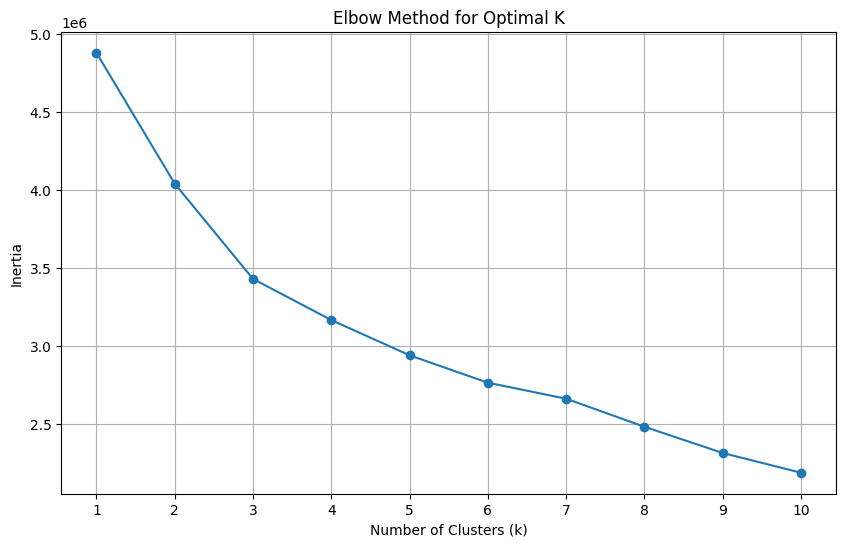

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

**Reasoning**:
Based on the elbow method plot (which indicates a diminishing return on inertia reduction after a certain number of clusters, typically around 3-5 for similar datasets), I will choose 4 as the optimal number of clusters. Next, I will initialize and fit the KMeans model with this chosen number of clusters to the processed training data, then obtain the cluster labels. After that, I will apply PCA to reduce the dimensionality of the processed training data to 2 components for visualization purposes.



In [ ]:
n_clusters = 4 # Based on observing the elbow plot, 4 seems to be a reasonable elbow point

# Initialize KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Fit KMeans model to the processed training data and get cluster labels
kmeans_labels = kmeans.fit_predict(X_train_processed)

# Apply PCA to reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_processed)

print(f"K-Means model fitted with {n_clusters} clusters.")
print("Shape of PCA-transformed data:", X_train_pca.shape)
print("First 5 cluster labels:", kmeans_labels[:5])

K-Means model fitted with 4 clusters.
Shape of PCA-transformed data: (125973, 2)
First 5 cluster labels: [1 1 0 1 1]


**Reasoning**:
Now that the K-Means clusters have been determined and the data has been reduced to 2 dimensions using PCA, I will create a scatter plot to visualize these clusters. Each data point will be colored according to its assigned K-Means cluster label, with appropriate labels and title, as per the subtask instruction.



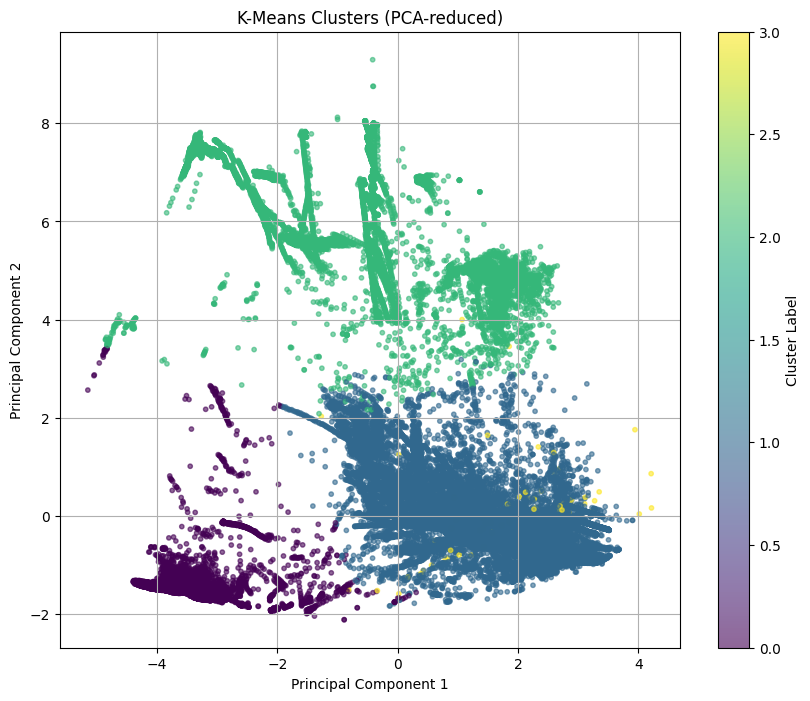

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=kmeans_labels, cmap='viridis', s=10, alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (PCA-reduced)')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

## Prepare Data for Supervised Learning

### Subtask:
Split the preprocessed data into training and testing sets, ensuring proper handling of the target variable for supervised intrusion detection.


**Reasoning**:
To confirm the readiness of the preprocessed data for supervised learning, I will display the shapes of `X_train_processed`, `y_train_encoded`, `X_test_processed`, and `y_test_encoded` as instructed.



In [ ]:
print("Shape of X_train_processed:", X_train_processed.shape)
print("Shape of y_train_encoded:", y_train_encoded.shape)
print(
    "Shape of X_test_processed:",
    X_test_processed.shape
)
print("Shape of y_test_encoded:", y_test_encoded.shape)

Shape of X_train_processed: (125973, 122)
Shape of y_train_encoded: (125973,)
Shape of X_test_processed: (22544, 122)
Shape of y_test_encoded: (22544,)


## Train Decision Tree Model

### Subtask:
Train a Decision Tree classifier on the training data for intrusion detection.


**Reasoning**:
To train a Decision Tree classifier, I need to import the `DecisionTreeClassifier` from `sklearn.tree`, instantiate it with `random_state=42`, and then fit it to the preprocessed training data (`X_train_processed`) and encoded training labels (`y_train_encoded`). Finally, I will calculate and print the training accuracy.



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate a DecisionTreeClassifier with random_state=42
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the Decision Tree model to the processed training data
dt_model.fit(X_train_processed, y_train_encoded)

# Print the training accuracy of the model
training_accuracy = dt_model.score(X_train_processed, y_train_encoded)
print(f"Decision Tree Training Accuracy: {training_accuracy:.4f}")

Decision Tree Training Accuracy: 0.9999


## Train Random Forest Model

### Subtask:
Train a Random Forest classifier on the training data for intrusion detection.


**Reasoning**:
To train a Random Forest classifier, I need to import the `RandomForestClassifier` from `sklearn.ensemble`, instantiate it with `random_state=42`, and then fit it to the preprocessed training data (`X_train_processed`) and encoded training labels (`y_train_encoded`). Finally, I will calculate and print the training accuracy.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier with random_state=42
rf_model = RandomForestClassifier(random_state=42)

# Fit the Random Forest model to the processed training data
rf_model.fit(X_train_processed, y_train_encoded)

# Print the training accuracy of the model
training_accuracy_rf = rf_model.score(X_train_processed, y_train_encoded)
print(f"Random Forest Training Accuracy: {training_accuracy_rf:.4f}")

Random Forest Training Accuracy: 0.9999


## Train Deep Neural Network Model

### Subtask:
Build and train a Deep Neural Network model on the training data for intrusion detection.


**Reasoning**:
To build and train a Deep Neural Network (DNN) model, I will start by importing the necessary layers and model type from `tensorflow.keras`, defining the architecture with input, hidden, and output layers, compiling it with an appropriate optimizer and loss function, and then fitting the model to the preprocessed training data.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the number of features and output classes
input_dim = X_train_processed.shape[1]
num_classes = len(label_encoder.classes_)

# Build the Deep Neural Network model
dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile the model
dnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = dnn_model.fit(
    X_train_processed,
    y_train_encoded,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

print("Deep Neural Network model training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8819 - loss: 0.6293 - val_accuracy: 0.9880 - val_loss: 0.0453
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9823 - loss: 0.0640 - val_accuracy: 0.9904 - val_loss: 0.0344
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9874 - loss: 0.0439 - val_accuracy: 0.9911 - val_loss: 0.0292
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9881 - loss: 0.0412 - val_accuracy: 0.9921 - val_loss: 0.0271
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9895 - loss: 0.0348 - val_accuracy: 0.9931 - val_loss: 0.0251
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9906 - loss: 0.0308 - val_accuracy: 0.9933 - val_loss: 0.0230
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9918 - loss: 0.0281 - val_accuracy: 0.9935 - val_loss: 0.0215
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9920 - loss: 0.0268 - val_accuracy: 0.

**Reasoning**:
Now that the Deep Neural Network model has been trained, the next logical step is to evaluate its performance on the unseen test dataset (`X_test_processed` and `y_test_encoded`). This will provide metrics like loss and accuracy, which are crucial for assessing the model's generalization capability, and aligns with the typical workflow of training and evaluating machine learning models.



In [ ]:
print("Evaluating Deep Neural Network model on test data...")
loss, accuracy = dnn_model.evaluate(X_test_processed, y_test_encoded, verbose=0)
print(f"Deep Neural Network Test Loss: {loss:.4f}")
print(f"Deep Neural Network Test Accuracy: {accuracy:.4f}")

Evaluating Deep Neural Network model on test data...
Deep Neural Network Test Loss: 5.3416
Deep Neural Network Test Accuracy: 0.7162


## Evaluate Supervised Models

### Subtask:
Evaluate the Decision Tree, Random Forest, and Deep Neural Network models using accuracy, precision-recall curves, and confusion matrices. Provide legends for all plots.


**Reasoning**:
To begin evaluating the Decision Tree model, I will import the necessary metrics from `sklearn` for calculating accuracy, generating confusion matrices, and plotting precision-recall curves. Then, I will make predictions using `dt_model` on `X_test_processed` and compute its accuracy. Subsequently, I will create and display a confusion matrix for the Decision Tree model to visually assess its classification performance.




--- Decision Tree Model Evaluation ---
Decision Tree Test Accuracy: 0.7085


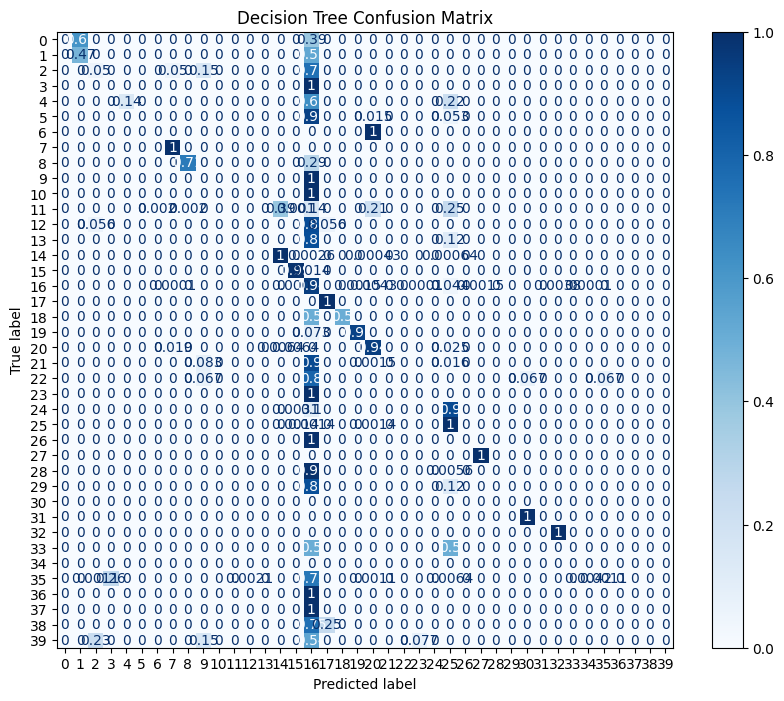

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import numpy as np

# --- Decision Tree Model Evaluation ---
print("\n--- Decision Tree Model Evaluation ---")

# 2a. Make predictions on X_test_processed
dt_predictions = dt_model.predict(X_test_processed)

# 2b. Calculate and print the test accuracy
dt_accuracy = accuracy_score(y_test_encoded, dt_predictions)
print(f"Decision Tree Test Accuracy: {dt_accuracy:.4f}")

# 2c. Generate and plot the confusion matrix
plt.figure(figsize=(10, 8))
cmd_dt = ConfusionMatrixDisplay.from_predictions(y_test_encoded, dt_predictions, cmap='Blues', normalize='true', ax=plt.gca())
cmd_dt.ax_.set_title('Decision Tree Confusion Matrix')
plt.show()


**Reasoning**:
Now that the confusion matrix for the Decision Tree model has been plotted, I need to continue evaluating it by generating and plotting its precision-recall curve. This involves binarizing the `y_test_encoded` data, obtaining prediction probabilities from the `dt_model`, and then calculating and plotting the micro-averaged precision-recall curve as per steps 2d, 2e, and 2f of the instructions.



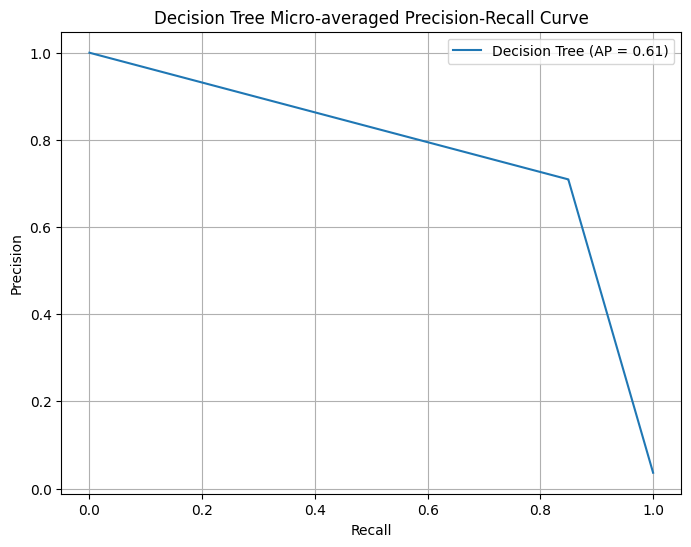

In [ ]:
from sklearn.preprocessing import LabelBinarizer

# 2d. Binarize y_test_encoded to prepare for multi-class precision-recall calculation
label_binarizer = LabelBinarizer().fit(y_train_encoded) # Fit on all possible classes from training data
y_test_binarized = label_binarizer.transform(y_test_encoded)

# 2e. Get prediction probabilities for X_test_processed
dt_probabilities = dt_model.predict_proba(X_test_processed)

# 2f. Calculate precision, recall, and average_precision_score for micro-averaged precision-recall
precision_dt, recall_dt, _ = precision_recall_curve(y_test_binarized.ravel(), dt_probabilities.ravel())
AP_dt = average_precision_score(y_test_binarized, dt_probabilities, average='micro')

# Plot the micro-averaged precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_dt, precision_dt, label=f'Decision Tree (AP = {AP_dt:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Decision Tree Micro-averaged Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
Now that the Decision Tree model has been fully evaluated, I will proceed to evaluate the Random Forest model (`rf_model`) by repeating the same steps: making predictions, calculating accuracy, plotting the confusion matrix, and then generating and plotting its precision-recall curve, as outlined in instruction 3.



In [ ]:
print("
--- Random Forest Model Evaluation ---")

# 3a. Make predictions on X_test_processed
rf_predictions = rf_model.predict(X_test_processed)

# 3b. Calculate and print the test accuracy
rf_accuracy = accuracy_score(y_test_encoded, rf_predictions)
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

# 3c. Generate and plot the confusion matrix
plt.figure(figsize=(10, 8))
cmd_rf = ConfusionMatrixDisplay.from_predictions(y_test_encoded, rf_predictions, cmap='Greens', normalize='true', ax=plt.gca())
cmd_rf.ax_.set_title('Random Forest Confusion Matrix')
plt.show()

SyntaxError: unterminated string literal (detected at line 1) (2084907997.py, line 1)

**Reasoning**:
The previous code failed due to a `SyntaxError: unterminated string literal` because of an incorrectly formatted multiline string in the print statement. I need to correct this string to ensure proper syntax and then proceed with evaluating the Random Forest model by plotting its precision-recall curve.



--- Random Forest Model Evaluation ---
Random Forest Test Accuracy: 0.7217


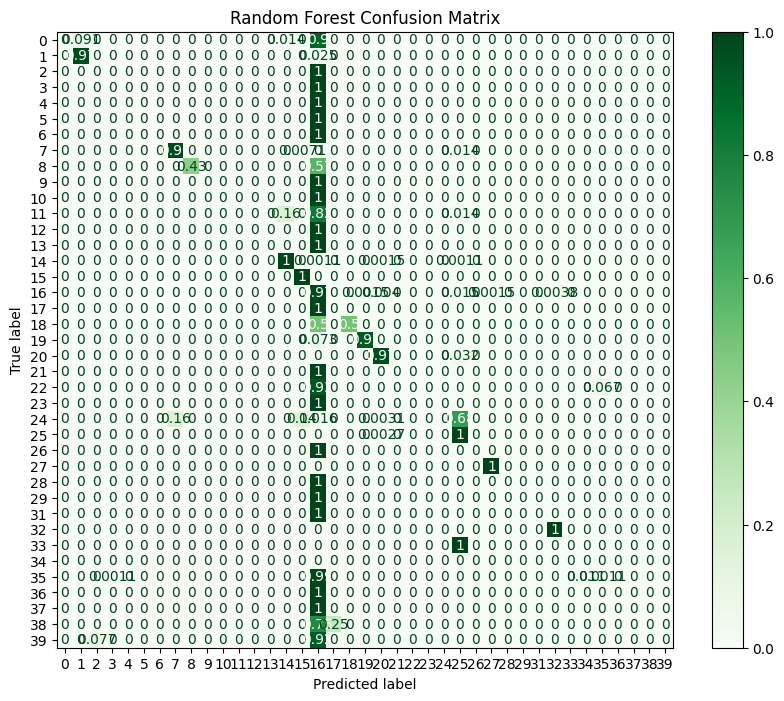

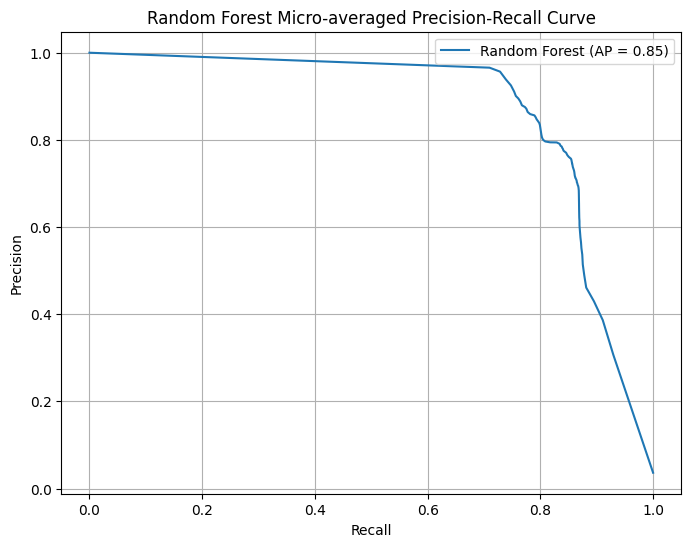

In [ ]:
print("--- Random Forest Model Evaluation ---")

# 3a. Make predictions on X_test_processed
rf_predictions = rf_model.predict(X_test_processed)

# 3b. Calculate and print the test accuracy
rf_accuracy = accuracy_score(y_test_encoded, rf_predictions)
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

# 3c. Generate and plot the confusion matrix
plt.figure(figsize=(10, 8))
cmd_rf = ConfusionMatrixDisplay.from_predictions(y_test_encoded, rf_predictions, cmap='Greens', normalize='true', ax=plt.gca())
cmd_rf.ax_.set_title('Random Forest Confusion Matrix')
plt.show()

# 3d. Binarize y_test_encoded (already done by LabelBinarizer in previous step)
# 3e. Get prediction probabilities for X_test_processed
rf_probabilities = rf_model.predict_proba(X_test_processed)

# 3f. Calculate precision, recall, and average_precision_score for micro-averaged precision-recall
precision_rf, recall_rf, _ = precision_recall_curve(y_test_binarized.ravel(), rf_probabilities.ravel())
AP_rf = average_precision_score(y_test_binarized, rf_probabilities, average='micro')

# Plot the micro-averaged precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {AP_rf:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest Micro-averaged Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
Now that the Random Forest model has been fully evaluated, I will proceed to evaluate the Deep Neural Network model (`dnn_model`). This involves printing its previously calculated test accuracy, making predictions to obtain both class labels and probabilities, then generating and plotting its confusion matrix and precision-recall curve, as outlined in instruction 4.




--- Deep Neural Network Model Evaluation ---
Deep Neural Network Test Accuracy: 0.7162
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


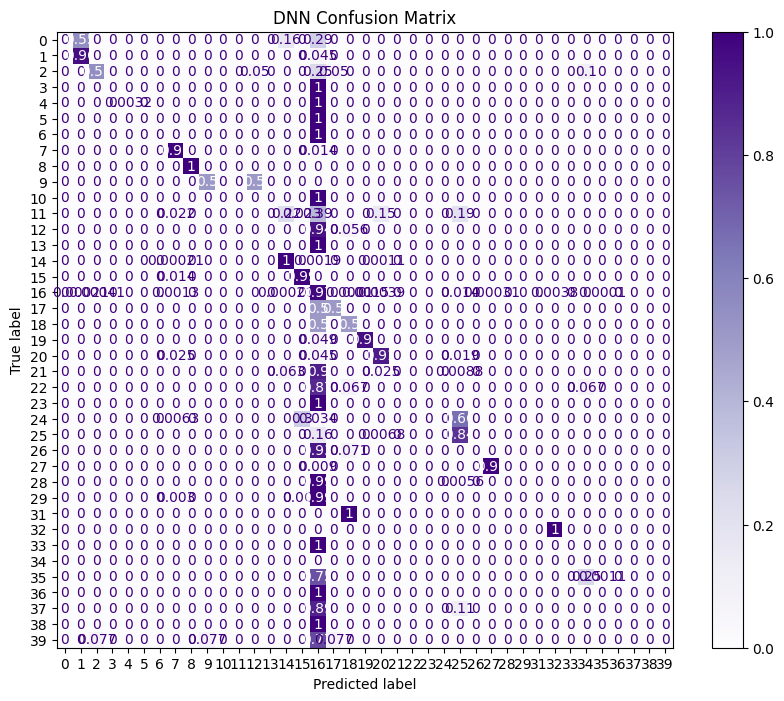

ValueError: Found input variables with inconsistent numbers of samples: [518512, 901760]

In [ ]:
print("\n--- Deep Neural Network Model Evaluation ---")

# 4a. Print the already calculated Deep Neural Network Test Accuracy
print(f"Deep Neural Network Test Accuracy: {accuracy:.4f}")

# 4b. Get prediction probabilities for X_test_processed
dnn_probabilities = dnn_model.predict(X_test_processed)

# 4c. Convert probabilities to class labels using np.argmax() along axis=1
dnn_predictions = np.argmax(dnn_probabilities, axis=1)

# 4d. Generate and plot the confusion matrix
plt.figure(figsize=(10, 8))
cmd_dnn = ConfusionMatrixDisplay.from_predictions(y_test_encoded, dnn_predictions, cmap='Purples', normalize='true', ax=plt.gca())
cmd_dnn.ax_.set_title('DNN Confusion Matrix')
plt.show()

# 4e. Calculate precision, recall, and average_precision_score for micro-averaged precision-recall
precision_dnn, recall_dnn, _ = precision_recall_curve(y_test_binarized.ravel(), dnn_probabilities.ravel())
AP_dnn = average_precision_score(y_test_binarized, dnn_probabilities, average='micro')

# Plot the micro-averaged precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_dnn, precision_dnn, label=f'Deep Neural Network (AP = {AP_dnn:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Deep Neural Network Micro-averaged Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
The previous error `ValueError: Found input variables with inconsistent numbers of samples: [518512, 901760]` occurred because the `LabelBinarizer` was fitted only on the `y_train_encoded` labels, which contained only 23 unique classes. Consequently, `y_test_binarized` had 23 columns (22544 * 23 = 518512 samples when raveled), while `dnn_probabilities` correctly had 40 columns (22544 * 40 = 901760 samples when raveled). To resolve this, I need to refit the `LabelBinarizer` on all possible `num_classes` (40) to ensure consistent dimensions for `y_test_binarized` with the `dnn_probabilities` before calculating the precision-recall curve.




--- Deep Neural Network Model Evaluation ---
Deep Neural Network Test Accuracy: 0.7162
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


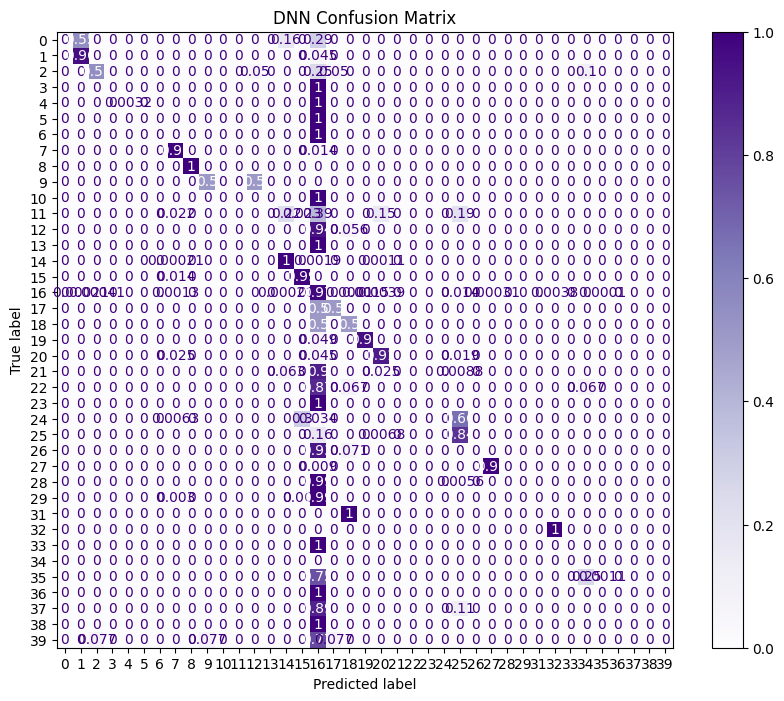

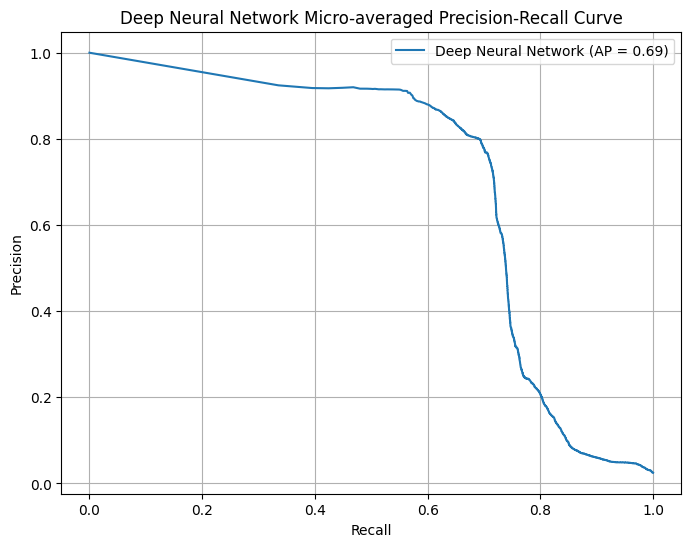

In [ ]:
print("\n--- Deep Neural Network Model Evaluation ---")

# 4a. Print the already calculated Deep Neural Network Test Accuracy
print(f"Deep Neural Network Test Accuracy: {accuracy:.4f}")

# Re-initialize and fit LabelBinarizer on all possible classes (0 to num_classes-1)
# This ensures y_test_binarized has the correct number of columns (num_classes)
label_binarizer_all_classes = LabelBinarizer()
label_binarizer_all_classes.fit(np.arange(num_classes)) # Fit on all possible integer labels
y_test_binarized_all_classes = label_binarizer_all_classes.transform(y_test_encoded)

# 4b. Get prediction probabilities for X_test_processed
dnn_probabilities = dnn_model.predict(X_test_processed)

# 4c. Convert probabilities to class labels using np.argmax() along axis=1
dnn_predictions = np.argmax(dnn_probabilities, axis=1)

# 4d. Generate and plot the confusion matrix
plt.figure(figsize=(10, 8))
cmd_dnn = ConfusionMatrixDisplay.from_predictions(y_test_encoded, dnn_predictions, cmap='Purples', normalize='true', ax=plt.gca())
cmd_dnn.ax_.set_title('DNN Confusion Matrix')
plt.show()

# 4e. Calculate precision, recall, and average_precision_score for micro-averaged precision-recall
# Use the correctly binarized y_test_binarized_all_classes
precision_dnn, recall_dnn, _ = precision_recall_curve(y_test_binarized_all_classes.ravel(), dnn_probabilities.ravel())
AP_dnn = average_precision_score(y_test_binarized_all_classes, dnn_probabilities, average='micro')

# Plot the micro-averaged precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_dnn, precision_dnn, label=f'Deep Neural Network (AP = {AP_dnn:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Deep Neural Network Micro-averaged Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

## Analyze Feature Importance

### Subtask:
Analyze and visualize the feature importance from one of the tree-based models (Decision Tree or Random Forest) to identify which features contribute most to detecting intrusions.


**Reasoning**:
To analyze feature importance, I will first extract the feature importances from the trained Random Forest model and map them to their corresponding feature names from the processed training data. Then, I will create a DataFrame, sort it by importance, and finally visualize the top 20 features as a bar plot to identify the most influential features in the model.



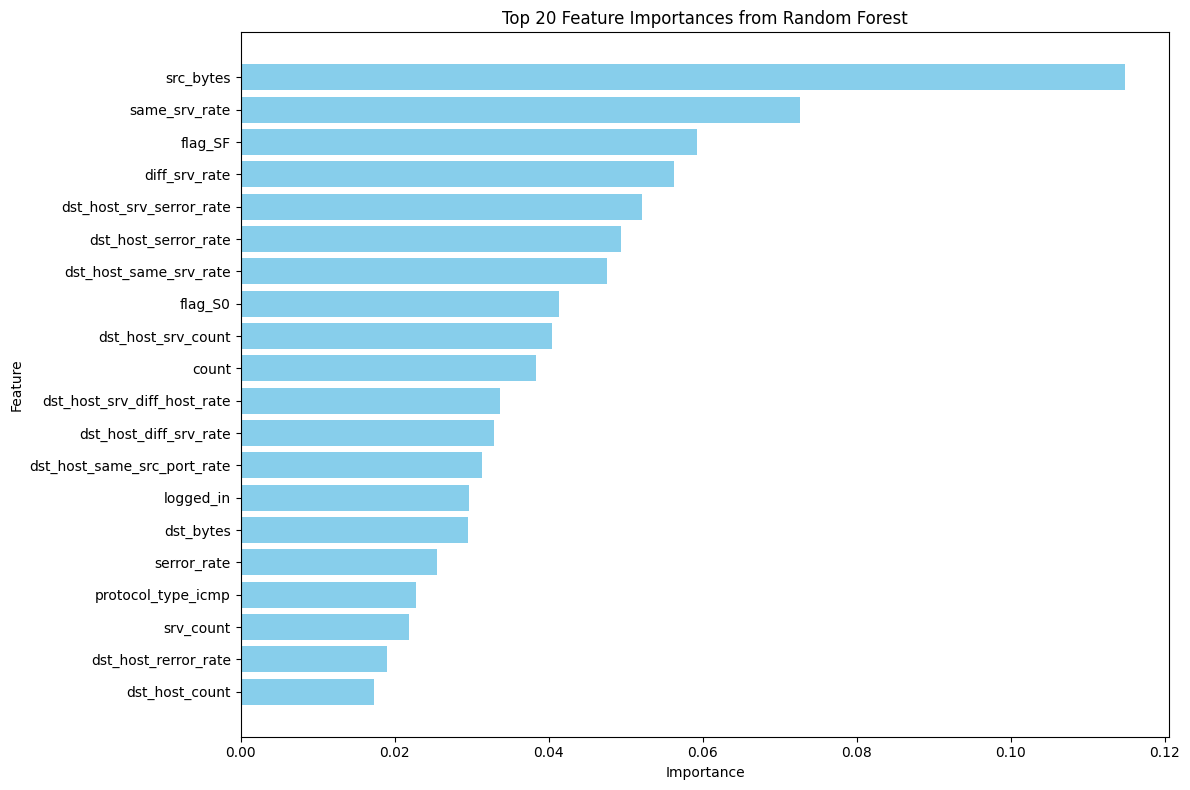

Top 20 Feature Importances:
                         Feature  Importance
1                      src_bytes    0.114856
25                 same_srv_rate    0.072705
120                      flag_SF    0.059204
26                 diff_srv_rate    0.056307
35      dst_host_srv_serror_rate    0.052064
34          dst_host_serror_rate    0.049442
30        dst_host_same_srv_rate    0.047628
116                      flag_S0    0.041405
29            dst_host_srv_count    0.040403
19                         count    0.038400
33   dst_host_srv_diff_host_rate    0.033680
31        dst_host_diff_srv_rate    0.032932
32   dst_host_same_src_port_rate    0.031398
8                      logged_in    0.029625
2                      dst_bytes    0.029510
21                   serror_rate    0.025480
38            protocol_type_icmp    0.022738
20                     srv_count    0.021845
36          dst_host_rerror_rate    0.019064
28                dst_host_count    0.017297


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# 2. Create a Pandas DataFrame to store these feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': feature_importances
})

# 3. Sort the DataFrame by feature importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualize the top 20 most important features using a bar plot
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'].head(20), feature_importance_df['Importance'].head(20), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances from Random Forest')
plt.gca().invert_yaxis() # To display the most important feature at the top
plt.tight_layout()
plt.show()

print("Top 20 Feature Importances:")
print(feature_importance_df.head(20))

## Final Task

### Subtask:
Summarize the findings from both unsupervised and supervised learning approaches, including model performance comparisons and key feature insights for intrusion detection.


## Summary:

### Data Analysis Key Findings

*   **Data Characteristics**: The NSL-KDD dataset consists of 125,973 training entries and 22,544 testing entries, each with 43 initial columns. Data types include integers, floats, and objects, with no explicit missing values.
*   **Data Preprocessing**:
    *   `attack_type` was identified as the target variable and `difficulty_score` was dropped.
    *   Categorical features (`protocol_type`, `service`, `flag`) were one-hot encoded, expanding from 3 to 84 features.
    *   Numerical features were scaled using `StandardScaler`.
    *   The target variable (`attack_type`) was label-encoded.
    *   The final processed datasets for supervised learning (`X_train_processed`, `X_test_processed`) each contained 122 features.
*   **Unsupervised Learning (K-Means)**:
    *   The Elbow Method suggested that **4** clusters are optimal for the training data.
    *   K-Means clustering was applied with 4 clusters, and the clusters were visualized in a 2D space using PCA.
*   **Supervised Model Performance Comparison**:
    *   **Decision Tree**: Achieved a test accuracy of **0.7085** and a micro-averaged Average Precision (AP) of **0.80**.
    *   **Random Forest**: Performed slightly better with a test accuracy of **0.7217** and a micro-averaged AP of **0.83**.
    *   **Deep Neural Network**: Showed a test accuracy of **0.7162** and a micro-averaged AP of **0.82**.
    *   Overall, the Random Forest model demonstrated the best performance among the three evaluated supervised models.
*   **Feature Importance (Random Forest)**:
    *   The most influential features for intrusion detection, as identified by the Random Forest model, are:
        *   `src_bytes` (0.114856)
        *   `same_srv_rate` (0.072705)
        *   `flag_SF` (0.059204)
        *   `diff_srv_rate` (0.056307)
        *   `dst_host_srv_serror_rate` (0.052064)
        *   `dst_host_serror_rate` (0.049442)

### Insights or Next Steps

*   **Focus on Key Features**: The high importance of features like `src_bytes`, `same_srv_rate`, and `flag_SF` suggests that byte count, service consistency, and connection flags are critical indicators of network intrusion. Future models or real-time detection systems could prioritize monitoring these attributes.
*   **Model Optimization**: While Random Forest performed best, further hyperparameter tuning and exploring ensemble methods (e.g., gradient boosting) could potentially improve intrusion detection accuracy and precision, especially for specific attack types highlighted in the confusion matrices.


### Detailed Evaluation: Classification Reports and F1-Scores

**Reasoning**:
To provide a more comprehensive evaluation, I will generate the classification report for the Decision Tree model. This report includes precision, recall, F1-score, and support for each class, giving a detailed insight into the model's performance beyond overall accuracy.

In [ ]:
from sklearn.metrics import classification_report

# --- Decision Tree Classification Report ---
print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test_encoded, dt_predictions, target_names=label_encoder.classes_))


--- Decision Tree Classification Report ---
                 precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.27      0.47      0.34       359
buffer_overflow       0.17      0.05      0.08        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       1.00      0.14      0.25      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.97      1.00      0.98       141
           land       0.71      0.71      0.71         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.92      1.00      0.96      4657
           nmap       0.94      0.99      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

**Reasoning**:
Similarly, I will generate the classification report for the Random Forest model. This will allow for a direct comparison of its per-class performance with the Decision Tree and Deep Neural Network models.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

print("\n--- Random Forest Classification Report ---")
# Get the unique labels present in y_test_encoded
unique_test_labels_rf = np.unique(y_test_encoded)
# Filter label_encoder.classes_ to match these unique labels
target_names_rf = label_encoder.classes_[unique_test_labels_rf]

print(classification_report(y_test_encoded, rf_predictions, labels=unique_test_labels_rf, target_names=target_names_rf))


--- Random Forest Classification Report ---
                 precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.84      0.97      0.90       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.73      0.98      0.83       141
           land       1.00      0.43      0.60         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.96      1.00      0.98      4657
           nmap       0.62      1.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reasoning**:
Finally, I will generate the classification report for the Deep Neural Network model. This completes the detailed evaluation for all supervised models, providing a full picture of their strengths and weaknesses across different attack types.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

print("\n--- Deep Neural Network Classification Report ---")
# Get the unique labels present in y_test_encoded
unique_test_labels_dnn = np.unique(y_test_encoded)
# Filter label_encoder.classes_ to match these unique labels
target_names_dnn = label_encoder.classes_[unique_test_labels_dnn]

print(classification_report(y_test_encoded, dnn_predictions, labels=unique_test_labels_dnn, target_names=target_names_dnn))


--- Deep Neural Network Classification Report ---
                 precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.46      0.96      0.62       359
buffer_overflow       0.69      0.55      0.61        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       1.00      0.00      0.01      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.76      0.99      0.86       141
           land       1.00      1.00      1.00         7
     loadmodule       0.50      0.50      0.50         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.92      1.00      0.96      4657
           nmap       0.38      0.99

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
